In [30]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

VIDEO_PATH = Path("/Users/rory/code/notwork/poi-v2/experiments/cv/data/raw/poi.mov")
# VIDEO_PATH = Path("/Users/rory/code/notwork/poi-v2/experiments/cv/data/raw/poi2.mov")
ARTIFACT_DIR = Path("/Users/rory/code/notwork/poi-v2/experiments/cv/artifacts/generated/real_video")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Video exists:", VIDEO_PATH.exists())
print("Artifacts:", ARTIFACT_DIR)

Video exists: True
Artifacts: /Users/rory/code/notwork/poi-v2/experiments/cv/artifacts/generated/real_video


In [31]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")


frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("frame_count =", frame_count)
print("fps =", fps)
print("width =", width)
print("height =", height)

frame_count = 1503
fps = 16.45166756204019
width = 1280
height = 720


In [32]:
def read_frame_at(frame_index: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(f"Could not read frame {frame_index}")

    return frame

sample_indices = [
    0,
    frame_count // 4,
    frame_count // 2,
    (3 * frame_count) // 4,
]

sample_indices = sorted(set(index for index in sample_indices if 0 <= index < frame_count))
print("sample_indices =", sample_indices)

sample_indices = [0, 375, 751, 1127]


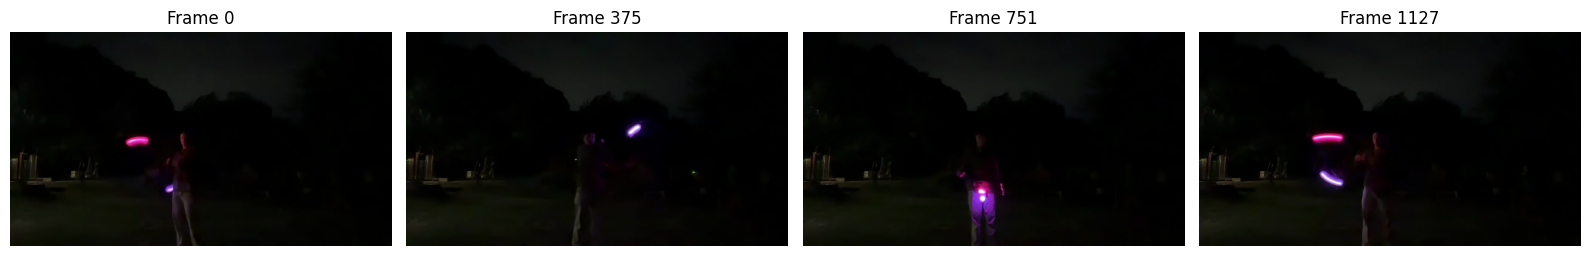

In [33]:
sample_frames = [read_frame_at(index) for index in sample_indices]

fig, axes = plt.subplots(1, len(sample_frames), figsize=(16, 4))

if len(sample_frames) == 1:
    axes = [axes]

for axis, frame, index in zip(axes, sample_frames, sample_indices):
    axis.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axis.set_title(f"Frame {index}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [34]:
sample_index = sample_indices[3* len(sample_indices) // 4]
sample_frame_bgr = read_frame_at(sample_index)
sample_frame_rgb = cv2.cvtColor(sample_frame_bgr, cv2.COLOR_BGR2RGB)
sample_frame_hsv = cv2.cvtColor(sample_frame_bgr, cv2.COLOR_BGR2HSV)
sample_frame_luma = cv2.cvtColor(sample_frame_bgr, cv2.COLOR_BGR2GRAY)

print("Using sample frame:", sample_index)

Using sample frame: 1127


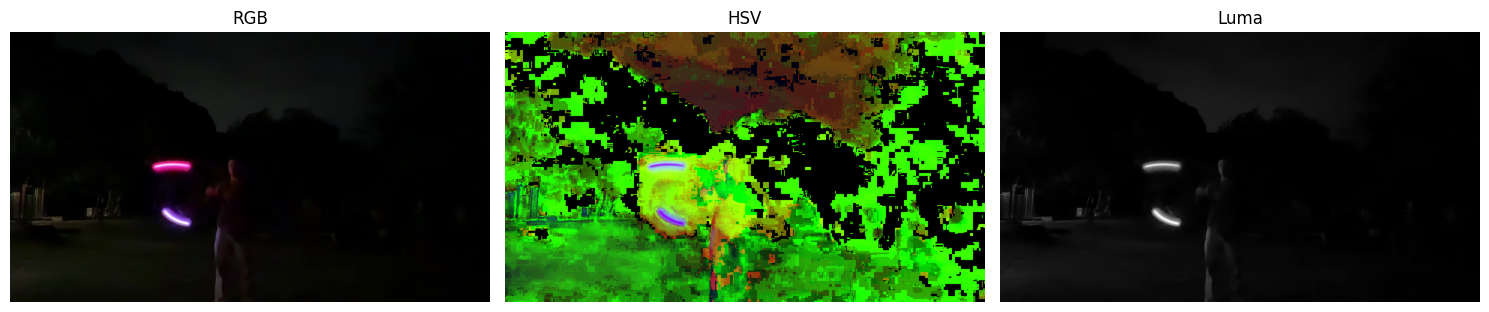

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_frame_rgb)
axes[0].set_title("RGB")

axes[1].imshow(sample_frame_hsv)
axes[1].set_title("HSV")

axes[2].imshow(sample_frame_luma, cmap="gray")
axes[2].set_title("Luma")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

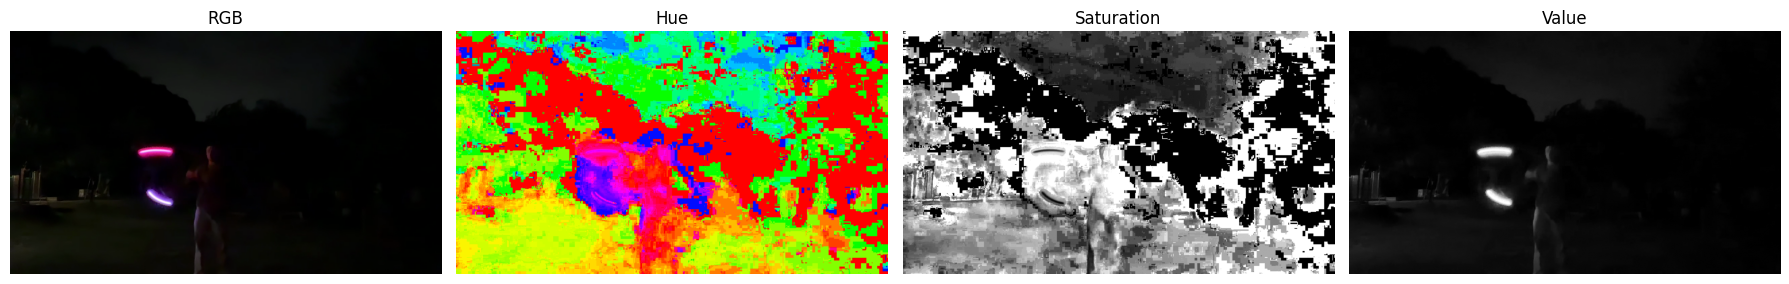

In [36]:
h = sample_frame_hsv[:, :, 0]
s = sample_frame_hsv[:, :, 1]
v = sample_frame_hsv[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(sample_frame_rgb)
axes[0].set_title("RGB")

axes[1].imshow(h, cmap="hsv")
axes[1].set_title("Hue")

axes[2].imshow(s, cmap="gray")
axes[2].set_title("Saturation")

axes[3].imshow(v, cmap="gray")
axes[3].set_title("Value")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

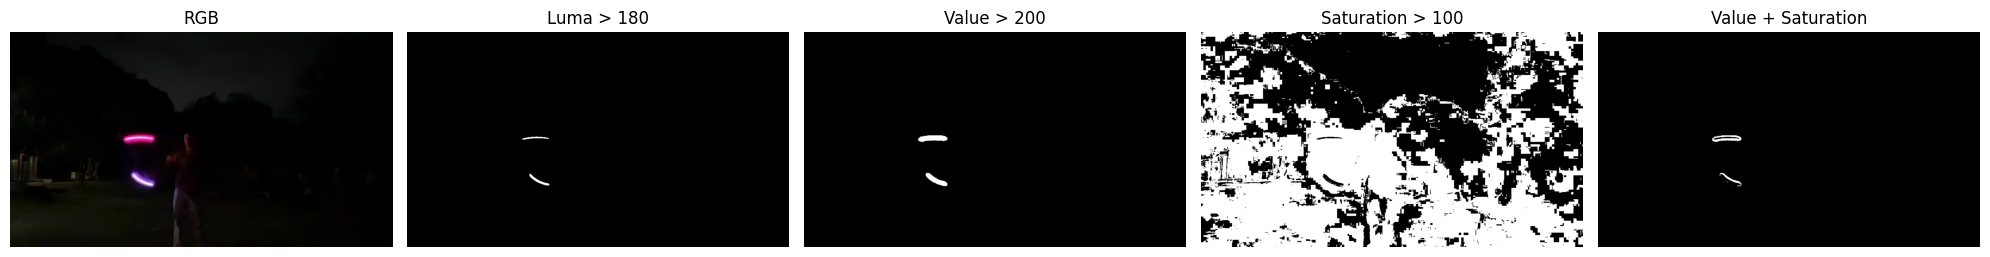

In [37]:
luma = sample_frame_luma
sat = s
val = v

luma_mask = cv2.inRange(luma, 180, 255)
value_mask = cv2.inRange(val, 200, 255)
sat_mask = cv2.inRange(sat, 100, 255)

combined_mask = cv2.bitwise_and(value_mask, sat_mask)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(sample_frame_rgb)
axes[0].set_title("RGB")

axes[1].imshow(luma_mask, cmap="gray")
axes[1].set_title("Luma > 180")

axes[2].imshow(value_mask, cmap="gray")
axes[2].set_title("Value > 200")

axes[3].imshow(sat_mask, cmap="gray")
axes[3].set_title("Saturation > 100")

axes[4].imshow(combined_mask, cmap="gray")
axes[4].set_title("Value + Saturation")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

In [38]:
def build_value_mask(frame_bgr: np.ndarray, threshold: int = 200) -> np.ndarray:
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    value = hsv[:, :, 2]
    mask = cv2.inRange(value, threshold, 255)
    return mask

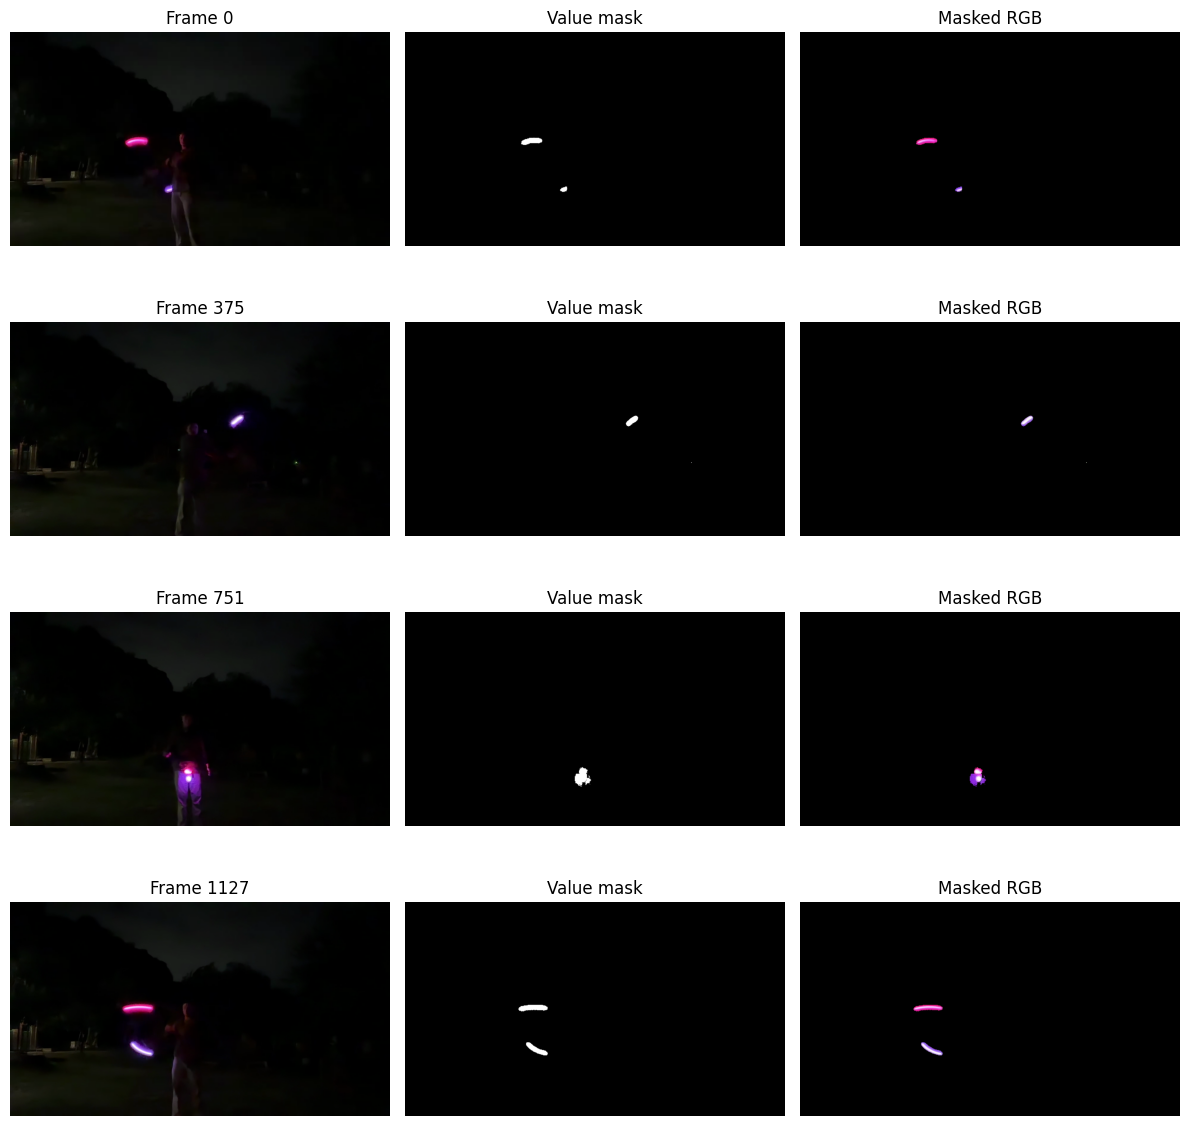

In [39]:
masked_frames = []
masks = []

for index in sample_indices:
    frame_bgr = read_frame_at(index)
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mask = build_value_mask(frame_bgr, threshold=200)

    masked_rgb = frame_rgb.copy()
    masked_rgb[mask == 0] = 0

    masks.append(mask)
    masked_frames.append(masked_rgb)

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 3 * len(sample_indices)))

if len(sample_indices) == 1:
    axes = np.array([axes])

for row, index in enumerate(sample_indices):
    frame_bgr = read_frame_at(index)
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(frame_rgb)
    axes[row, 0].set_title(f"Frame {index}")

    axes[row, 1].imshow(masks[row], cmap="gray")
    axes[row, 1].set_title("Value mask")

    axes[row, 2].imshow(masked_frames[row])
    axes[row, 2].set_title("Masked RGB")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

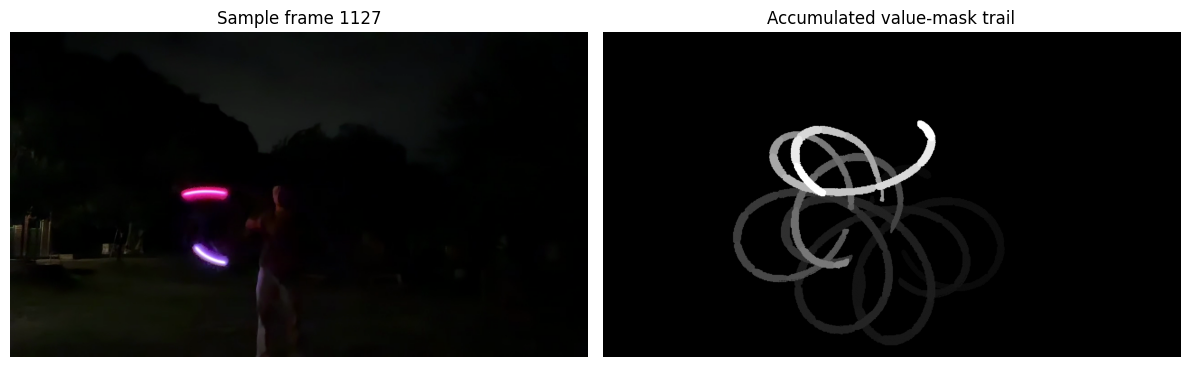

In [ ]:
accumulator = np.zeros((height, width), dtype=np.float32)
fade = 0.92

start_frame = max(0, sample_index - 20)
end_frame = min(frame_count, sample_index + 20)

for frame_index in range(start_frame, end_frame):
    frame_bgr = read_frame_at(frame_index)
    mask = build_value_mask(frame_bgr, threshold=200)
    accumulator = np.maximum(accumulator * fade, mask / 255.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sample_frame_rgb)
axes[0].set_title(f"Sample frame {sample_index}")

axes[1].imshow(accumulator, cmap="gray")
axes[1].set_title("Accumulated value-mask trail")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()


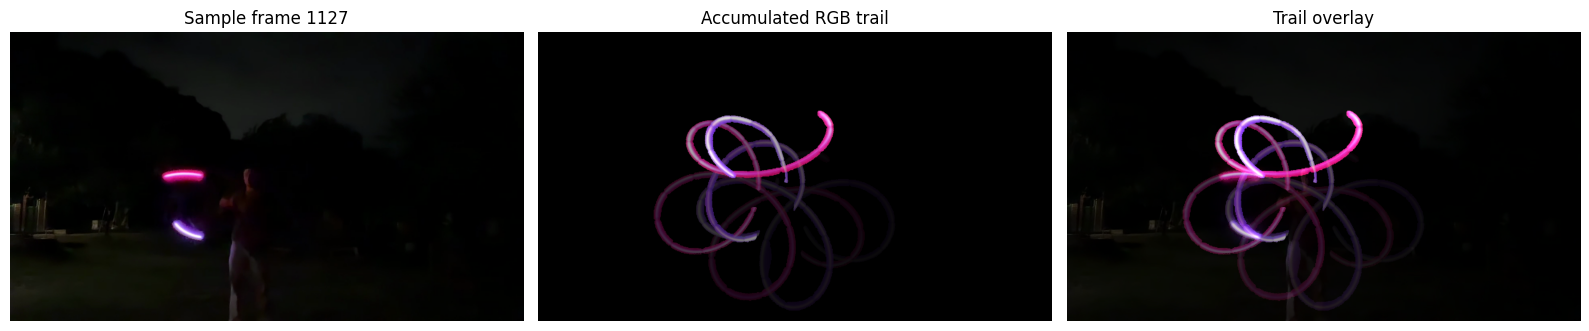

In [44]:
accumulator_rgb = np.zeros((height, width, 3), dtype=np.float32)
fade = 0.92

start_frame = max(0, sample_index - 20)
end_frame = min(frame_count, sample_index + 20)

for frame_index in range(start_frame, end_frame):
    frame_bgr = read_frame_at(frame_index)
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mask = build_value_mask(frame_bgr, threshold=200)

    masked_rgb = np.zeros_like(frame_rgb)
    masked_rgb[mask > 0] = frame_rgb[mask > 0]

    accumulator_rgb = np.maximum(accumulator_rgb * fade, masked_rgb)

base_rgb = sample_frame_rgb.astype(np.float32) / 255.0
overlay_rgb = np.clip(base_rgb * 0.55 + accumulator_rgb * 1.2, 0.0, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(sample_frame_rgb)
axes[0].set_title(f"Sample frame {sample_index}")

axes[1].imshow(accumulator_rgb)
axes[1].set_title("Accumulated RGB trail")

axes[2].imshow(overlay_rgb)
axes[2].set_title("Trail overlay")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

In [45]:
def build_trail_overlay_frames(
    start_frame: int,
    end_frame: int,
    threshold: int = 200,
    fade: float = 0.92,
    base_mix: float = 0.55,
    trail_mix: float = 1.2,
) -> list[np.ndarray]:
    accumulator_rgb = np.zeros((height, width, 3), dtype=np.float32)
    output_frames: list[np.ndarray] = []

    for frame_index in range(start_frame, end_frame):
        frame_bgr = read_frame_at(frame_index)
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        mask = build_value_mask(frame_bgr, threshold=threshold)

        masked_rgb = np.zeros_like(frame_rgb)
        masked_rgb[mask > 0] = frame_rgb[mask > 0]

        accumulator_rgb = np.maximum(accumulator_rgb * fade, masked_rgb)
        overlay_rgb = np.clip(frame_rgb * base_mix + accumulator_rgb * trail_mix, 0.0, 1.0)

        output_frames.append(overlay_rgb)

    return output_frames

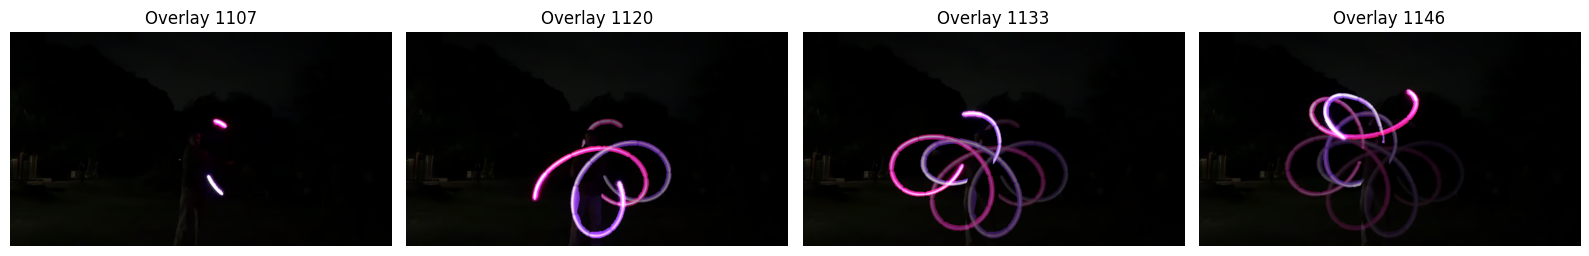

In [46]:
preview_start = max(0, sample_index - 20)
preview_end = min(frame_count, sample_index + 20)

overlay_frames = build_trail_overlay_frames(
    start_frame=preview_start,
    end_frame=preview_end,
    threshold=200,
    fade=0.92,
    base_mix=0.55,
    trail_mix=1.2,
)

preview_positions = [0, len(overlay_frames) // 3, 2 * len(overlay_frames) // 3, len(overlay_frames) - 1]
preview_positions = sorted(set(preview_positions))

fig, axes = plt.subplots(1, len(preview_positions), figsize=(16, 4))

if len(preview_positions) == 1:
    axes = [axes]

for axis, position in zip(axes, preview_positions):
    axis.imshow(overlay_frames[position])
    axis.set_title(f"Overlay {preview_start + position}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [47]:
output_path = ARTIFACT_DIR / "poi_value_trail_overlay.mov"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

if not writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {output_path}")

for overlay_rgb in overlay_frames:
    overlay_bgr_u8 = cv2.cvtColor((overlay_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    writer.write(overlay_bgr_u8)

writer.release()

print("Saved overlay video to:", output_path)

Saved overlay video to: /Users/rory/code/notwork/poi-v2/experiments/cv/artifacts/generated/real_video/poi_value_trail_overlay.mov


In [48]:
def render_full_video_overlay(
    input_path: Path,
    output_path: Path,
    threshold: int = 200,
    fade: float = 0.92,
    base_mix: float = 0.55,
    trail_mix: float = 1.2,
    write_trail_only: bool = False,
) -> None:
    cap = cv2.VideoCapture(str(input_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open input video: {input_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    if not writer.isOpened():
        cap.release()
        raise RuntimeError(f"Could not open output video: {output_path}")

    trail_writer = None
    if write_trail_only:
        trail_only_path = output_path.with_name(output_path.stem + "_trail_only.mp4")
        trail_writer = cv2.VideoWriter(str(trail_only_path), fourcc, fps, (width, height))
        if not trail_writer.isOpened():
            writer.release()
            cap.release()
            raise RuntimeError(f"Could not open trail-only output video: {trail_only_path}")

    accumulator_rgb = np.zeros((height, width, 3), dtype=np.float32)

    frame_index = 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        mask = build_value_mask(frame_bgr, threshold=threshold)

        masked_rgb = np.zeros_like(frame_rgb)
        masked_rgb[mask > 0] = frame_rgb[mask > 0]

        accumulator_rgb = np.maximum(accumulator_rgb * fade, masked_rgb)
        overlay_rgb = np.clip(frame_rgb * base_mix + accumulator_rgb * trail_mix, 0.0, 1.0)

        overlay_bgr_u8 = cv2.cvtColor((overlay_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        writer.write(overlay_bgr_u8)

        if trail_writer is not None:
            trail_bgr_u8 = cv2.cvtColor((accumulator_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
            trail_writer.write(trail_bgr_u8)

        frame_index += 1
        if frame_index % 100 == 0:
            print(f"Processed {frame_index}/{frame_count} frames")

    cap.release()
    writer.release()
    if trail_writer is not None:
        trail_writer.release()

    print("Finished")
    print("Overlay video:", output_path)
    if write_trail_only:
        print("Trail-only video:", trail_only_path)

In [49]:
full_output_path = ARTIFACT_DIR / "poi_full_value_trail_overlay.mp4"

render_full_video_overlay(
    input_path=VIDEO_PATH,
    output_path=full_output_path,
    threshold=200,
    fade=0.92,
    base_mix=0.55,
    trail_mix=1.2,
    write_trail_only=True,
)

Processed 100/1503 frames
Processed 200/1503 frames
Processed 300/1503 frames
Processed 400/1503 frames
Processed 500/1503 frames
Processed 600/1503 frames
Processed 700/1503 frames
Processed 800/1503 frames
Processed 900/1503 frames
Processed 1000/1503 frames
Processed 1100/1503 frames
Processed 1200/1503 frames
Processed 1300/1503 frames
Processed 1400/1503 frames
Processed 1500/1503 frames
Finished
Overlay video: /Users/rory/code/notwork/poi-v2/experiments/cv/artifacts/generated/real_video/poi_full_value_trail_overlay.mp4
Trail-only video: /Users/rory/code/notwork/poi-v2/experiments/cv/artifacts/generated/real_video/poi_full_value_trail_overlay_trail_only.mp4
